In [1]:
%load_ext autoreload
%autoreload 2
import sys
if ".." not in sys.path:
    sys.path.append("..")

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import yfinance as yf
import pandas as pd

from signature.learning.signature_transform import RollingSignatureTransform, EFMSignatureTransform
from signature.learning.hyperparameters_optimization import optimize_lam_cv, grid_search_cv
import signature.tensor_algebra as ta

my_green = "#5b6c64"
my_copper = "#B56246"
plt.rcParams["figure.figsize"]        = ((1 + np.sqrt(5)) / 2 * 5, 5)
plt.rcParams["figure.autolayout"]     = True
plt.rcParams["patch.force_edgecolor"] = False
plt.rcParams["axes.grid"]             = True
plt.rcParams['axes.prop_cycle']       = matplotlib.cycler(color=[my_green, my_copper, "#322B4D", "#28BC9C", "#71074E"])

## Data

In [2]:
df = pd.read_excel("data/EEX_TTF.xlsx", index_col=0)
df.rename(
    columns={
        "TTF_FUTURE_CALENDAR_PRICE C+1 (EUR/MWh)": "C+1",
        "TTF_FUTURE_CALENDAR_PRICE C+2 (EUR/MWh)": "C+2",
        "TTF_FUTURE_CALENDAR_PRICE C+3 (EUR/MWh)": "C+3",
        "TTF_FUTURE_MONTH_PRICE M+1 (EUR/MWh)": "M+1",
        "TTF_FUTURE_MONTH_PRICE M+2 (EUR/MWh)": "M+2",
        "TTF_FUTURE_MONTH_PRICE M+3 (EUR/MWh)": "M+3",
        "TTF_FUTURE_QUARTER_PRICE Q+1 (EUR/MWh)": "Q+1",
        "TTF_FUTURE_QUARTER_PRICE Q+2 (EUR/MWh)": "Q+2",
        "TTF_FUTURE_QUARTER_PRICE Q+3 (EUR/MWh)": "Q+3",
        "TTF_FUTURE_SEASON_PRICE S+1 (EUR/MWh)": "S+1",
        "TTF_FUTURE_SEASON_PRICE S+2 (EUR/MWh)": "S+2",
    },
    inplace=True
)
df.index = df.index.normalize()
df = df.dropna()

# List of dates to remove (arbitrage)
unwanted_dates = ['2022-03-30', '2022-03-31', '2024-12-31', '2024-12-30', '2021-12-31', '2021-12-30']
# Keep rows where the date is NOT in the unwanted list
df = df[~df.index.isin(unwanted_dates)]

df

/var/folders/mc/53434rwj3q3_5f334ttcrq280000gn/T/ipykernel_4115/2404357534.py:24: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df = df[~df.index.isin(unwanted_dates)]


,C+1,C+2,C+3,M+1,M+2,M+3,Q+1,Q+2,Q+3,S+1,S+2
Date,,,,,,,,,,,
2013-02-08,26.880,26.610,25.980,26.050,26.030,25.970,25.990,25.980,27.370,25.990,27.590
2013-02-11,26.650,26.430,25.840,25.680,25.680,25.630,25.680,25.610,27.090,25.650,27.340
2013-02-12,26.560,26.350,25.800,25.700,25.700,25.650,25.700,25.650,26.950,25.670,27.210
2013-02-13,26.530,26.300,25.740,25.690,25.680,25.640,25.670,25.600,26.980,25.640,27.220
2013-02-14,26.610,26.400,25.780,25.890,25.870,25.790,25.840,25.760,27.110,25.800,27.350
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-27,44.051,30.769,25.021,53.996,54.319,54.310,54.210,54.296,54.729,54.253,54.378
2026-03-30,44.285,30.984,25.028,54.718,54.919,54.914,54.907,55.116,54.245,54.685,41.614
2026-03-31,41.269,29.584,24.820,50.851,50.862,50.883,50.821,50.831,49.712,50.278,38.889


In [3]:
train_start_date = pd.to_datetime('2015-01-01')
test_start_date = pd.to_datetime('2021-01-01') # pd.to_datetime('2019-01-01')
test_end_date = pd.to_datetime('2023-01-01')

In [4]:
index = df.index
price = np.array(df["M+1"])

burn_in = np.where(index >= train_start_date)[0][0]
print("Burn-in:", burn_in)

Burn-in: 446


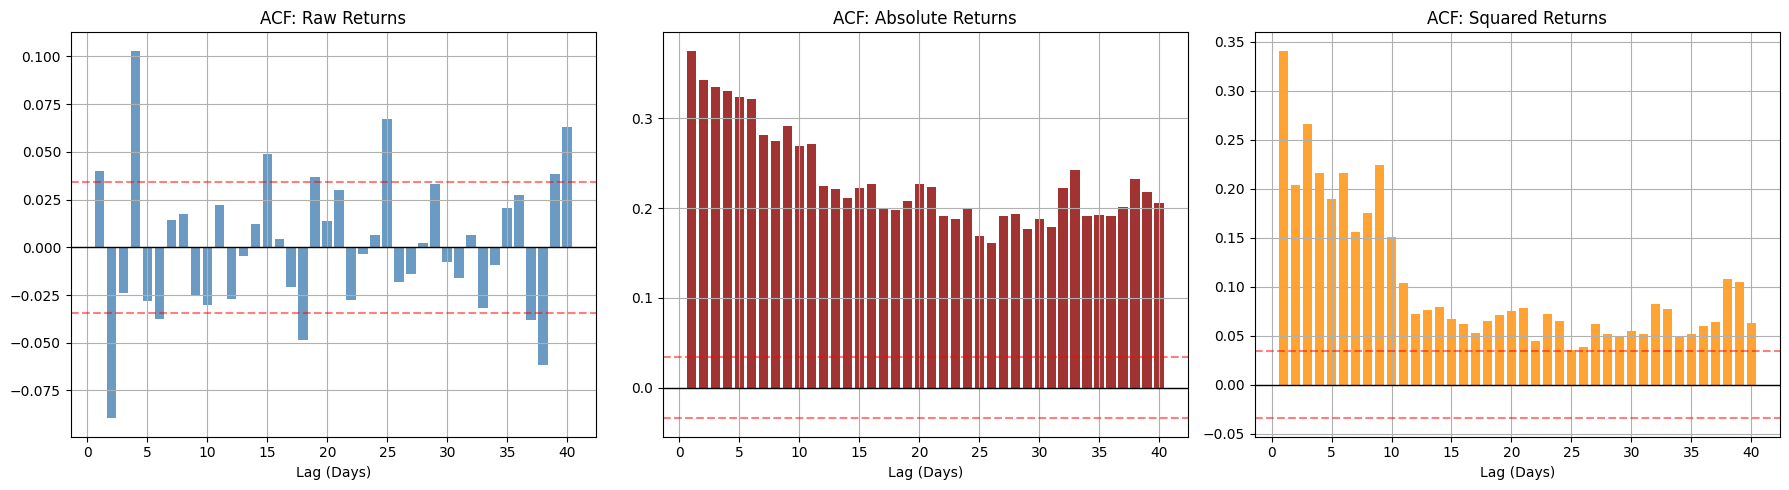

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

# Assuming 'spx' is your array of daily log-returns or price increments
# If 'spx' is price levels, use: returns = np.diff(np.log(spx))
returns = np.diff(np.log(price))

lags = 40
acf_raw = acf(returns, nlags=lags, fft=True)
acf_abs = acf(np.abs(returns), nlags=lags, fft=True)
acf_sq  = acf(returns**2, nlags=lags, fft=True)

# Plotting the three perspectives
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lags_idx = np.arange(lags + 1)
conf_interval = 1.96 / np.sqrt(len(returns)) # 95% Confidence Band

titles = ['ACF: Raw Returns', 'ACF: Absolute Returns', 'ACF: Squared Returns']
data_list = [acf_raw, acf_abs, acf_sq]
colors = ['steelblue', 'darkred', 'darkorange']

for i in range(3):
    axes[i].bar(lags_idx[1:], data_list[i][1:], color=colors[i], alpha=0.8)
    axes[i].axhline(y=0, color='black', lw=1)
    axes[i].axhline(y=conf_interval, color='red', linestyle='--', alpha=0.5)
    axes[i].axhline(y=-conf_interval, color='red', linestyle='--', alpha=0.5)
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Lag (Days)')

plt.tight_layout()
plt.show()

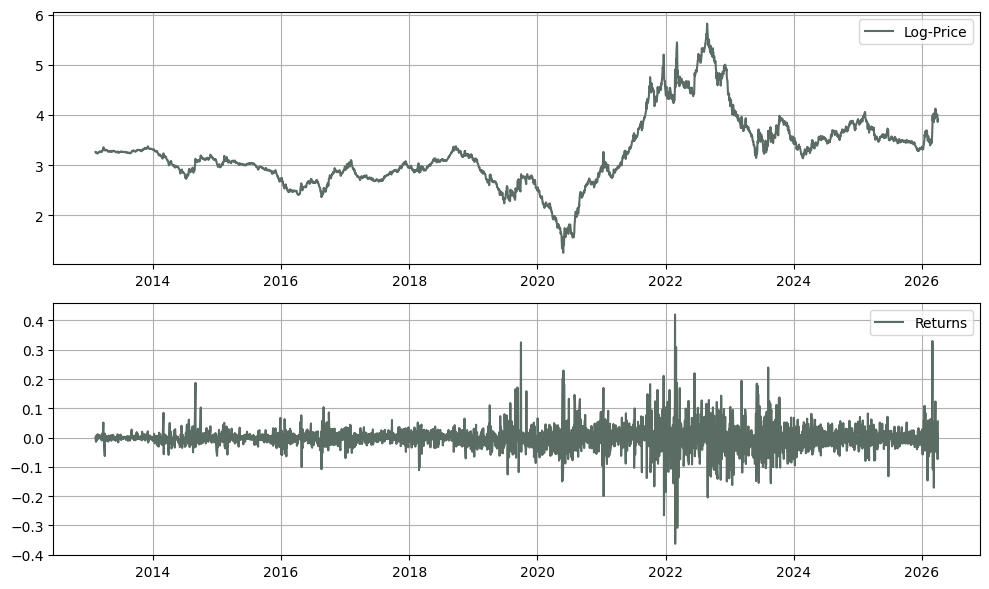

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

time_grid = np.array((index - index[0]).days / 365)
dates_grid = pd.to_datetime(pd.Series(index))

ax[0].plot(dates_grid, np.log(price), label="Log-Price")
ax[0].legend()

ax[1].plot(dates_grid, np.diff(np.log(price), prepend=np.log(price)[0:1]), label="Returns")
ax[1].legend()

## EFM-Signature model

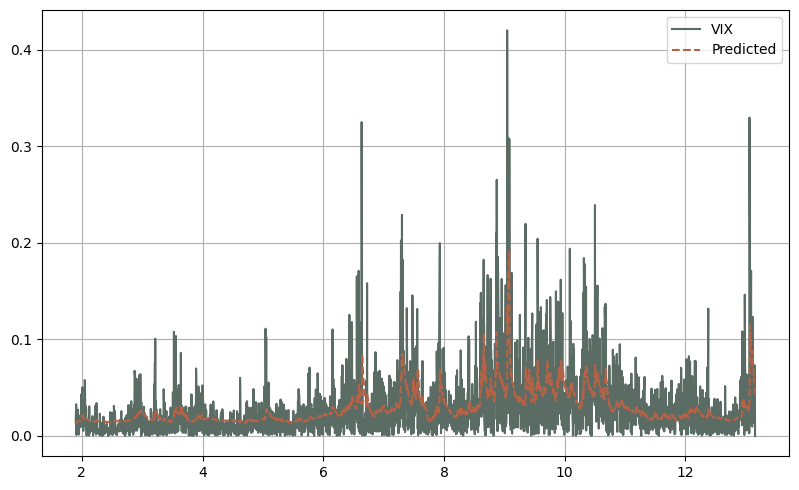

In [49]:
# path = np.vstack([
#     time_grid,
#     np.log(spx),
# ]).T
# trunc = 2
# lam = np.array([2, 8])
# kwargs = {"lead_lag": True, "lead_lag_idx": jnp.array([1]), "lam_idx": [0, 1, 1]}

path = np.vstack([
    time_grid,
    np.log(price) / 10,
    np.concatenate([[0], np.cumsum(np.diff(np.log(price))**2)]) * 2,
]).T
trunc = 2
lam = np.array([10, 10, 10])
kwargs = {}

# path = np.vstack([
#     time_grid,
#     np.log(spx),
#     np.concatenate([np.log(spx)[0:1], np.log(spx)[0:-1]]),
# ]).T
# trunc = 3
# lam = np.array([9, 1])
# kwargs = {"lam_idx": [0, 1, 1]}


dim = path.shape[1]
if "lead_lag_idx" in kwargs:
    dim += kwargs["lead_lag_idx"].size

X = np.hstack([time_grid[:, None], path])
# y = np.array(vix[burn_in:])

spx_abs_returns = np.abs(np.diff(np.log(price), append=np.log(price)[-1:]))
y = spx_abs_returns[burn_in:]

pipe = Pipeline([
    ('sig', EFMSignatureTransform(trunc=trunc, lam=lam, burn_in=burn_in, **kwargs)),
    ('scaler', StandardScaler()),
    ('regressor', Ridge())
])

pipe.fit(X, y)

plt.plot(time_grid[burn_in:], y, label="VIX")
plt.plot(time_grid[burn_in:], pipe.predict(X), "--", label="Predicted")
plt.legend()

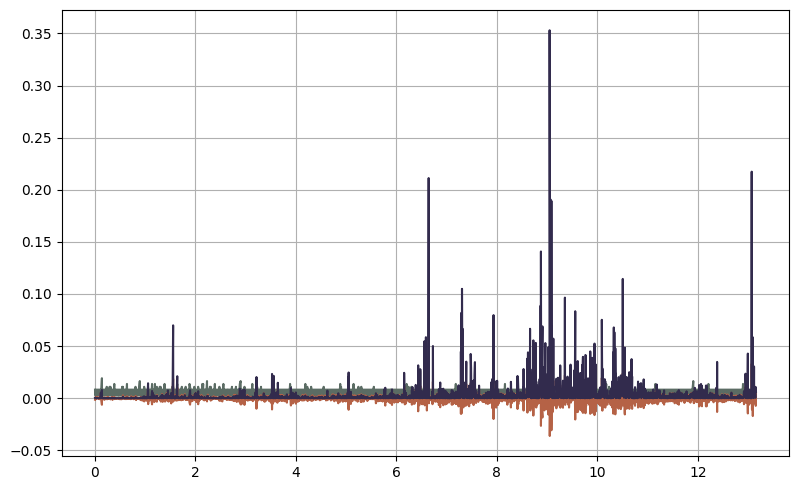

In [50]:
plt.plot(time_grid[1:], np.diff(path[:, 0], axis=0))
plt.plot(time_grid[1:], np.diff(path[:, 1], axis=0))
plt.plot(time_grid[1:], np.diff(path[:, 2], axis=0))

### Optimize the hyper-parameters

In [53]:
# 1. Define the split point
# Assuming X is the full path and y is already sliced by burn_in: vix[burn_in:]
test_start_idx = np.where(index >= test_start_date)[0][0]
test_end_idx = np.where(index >= test_end_date)[0][0]


# 2. Adjust indices for the 'y' scale
# Since y starts at 'burn_in', we shift the test_start_idx to match y's indexing
y_test_start = test_start_idx - burn_in
y_test_end = test_end_idx - burn_in

if y_test_start <= 0:
    raise ValueError("test_start_idx must be significantly larger than burn_in.")

# 3. Create the Split
X_train, X_test = X[:test_start_idx], X[:test_end_idx]  # X_test is full path to maintain EFM state
y_train, y_test = y[:y_test_start], y[y_test_start:y_test_end]

# 4. Learn the optimal lambdas
lam_dim = 3
lam_opt = optimize_lam_cv(X=X_train, y=y_train, model=pipe, burn_in=burn_in,
                          bounds=[(10, 40)] * lam_dim, init_guess=[5] * lam_dim,
                          optimizer="Powell")
pipe.set_params(sig__lam=lam_opt)

# 0.0010586263195815357
# 0.00087 BFGS 1.492e+01  2.000e+01  1.562e+00
# 0.000826 BFGS 2.000e+00  1.000e+01  2.923e+00

# # Grid search for the rolling signature
# param_grid = {
#     'sig__trunc': [2, 3, 4],
#     'sig__window_size': np.arange(1, 11),
#     'regressor__alpha': [0.1, 1.0, 10.0]
# }
# best_params, all_results = grid_search_cv_efm(X=X_train, y=y_train, model=pipe, param_grid=param_grid, burn_in=burn_in)
# pipe.set_params(**best_params)

/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:98: OptimizeWarning: Initial guess is not within the specified bounds
  res = minimize(


Testing lam: [5. 5. 5.] | CV MSE: 0.021343
Testing lam: [21.45898034  5.          5.        ] | CV MSE: 0.015531
Testing lam: [28.54101966  5.          5.        ] | CV MSE: 0.012668
Testing lam: [32.91796068  5.          5.        ] | CV MSE: 0.011360
Testing lam: [35.62305899  5.          5.        ] | CV MSE: 0.010686
Testing lam: [37.29490169  5.          5.        ] | CV MSE: 0.010313
Testing lam: [38.3281573  5.         5.       ] | CV MSE: 0.010097
Testing lam: [38.96674439  5.          5.        ] | CV MSE: 0.009968
Testing lam: [39.36141291  5.          5.        ] | CV MSE: 0.009891
Testing lam: [39.60533148  5.          5.        ] | CV MSE: 0.009844
Testing lam: [39.75608144  5.          5.        ] | CV MSE: 0.009815
Testing lam: [39.84925004  5.          5.        ] | CV MSE: 0.009797
Testing lam: [39.9068314  5.         5.       ] | CV MSE: 0.009786
Testing lam: [39.94241864  5.          5.        ] | CV MSE: 0.009779
Testing lam: [39.96441276  5.          5.        ] | 

Pipeline(steps=[('sig',
                 EFMSignatureTransform(burn_in=446,
                                       lam=array([39.97887828, 32.1750887 , 39.99998811]),
                                       trunc=2)),
                ('scaler', StandardScaler()), ('regressor', Ridge())])

Train Metrics: RMSE = 0.0209, R2 = 0.2212
Test Metrics: RMSE = 0.1765, R2 = -10.8190


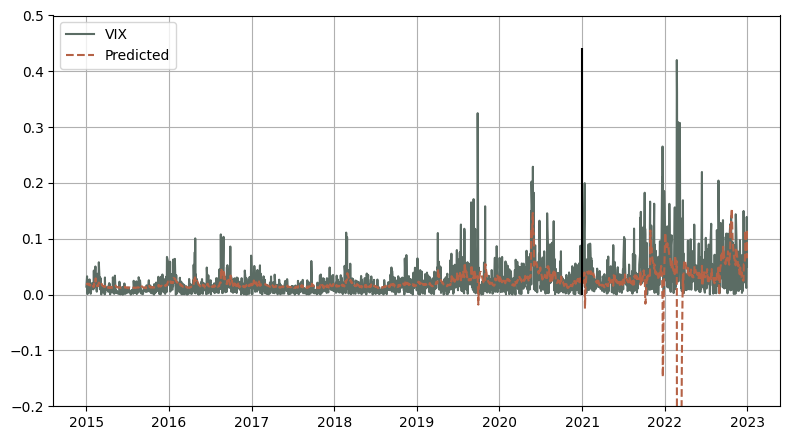

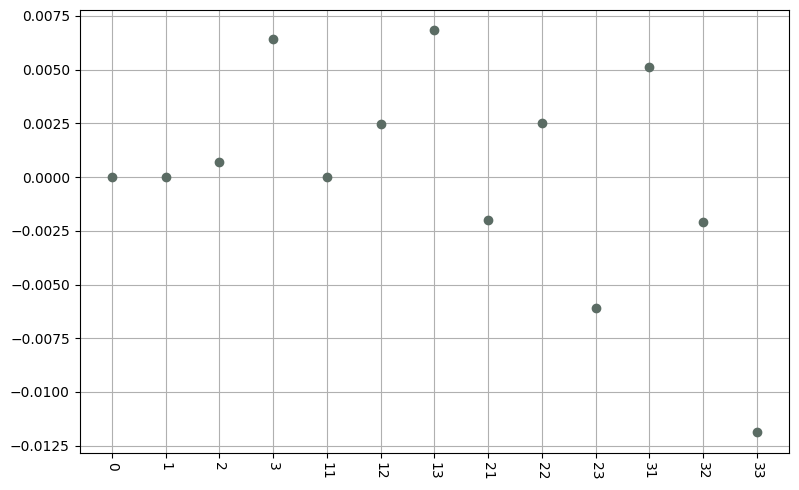

In [60]:
# 5. Fit on Train Data
# Note: y_train is already aligned with the output of sig.transform(X_train)
pipe.fit(X_train, y_train)

# 6. Predict
y_pred_train = pipe.predict(X_train)
y_pred_test = pipe.predict(X_test)[y_test_start:] # Slice the test prediction to match y_test

# 7. Compute Metrics
metrics = {
    "Train": {
        "RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "R2": r2_score(y_train, y_pred_train)
    },
    "Test": {
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "R2": r2_score(y_test, y_pred_test)
    }
}

for split, results in metrics.items():
    print(f"{split} Metrics: RMSE = {results['RMSE']:.4f}, R2 = {results['R2']:.4f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(dates_grid[(index >= train_start_date) & (index <= test_end_date)], y[:y_test_end], label="VIX")
ax.plot(dates_grid[(index >= train_start_date) & (index <= test_end_date)], pipe.predict(X_test), "--", label="Predicted")
ax.vlines(x=test_start_date, ymin=0.95 * np.min(y), ymax=1.05 * np.max(y), color="k")
ax.legend(loc="upper left")
ax.set_ylim([-0.2, 0.5])

plt.show()
# fig.savefig("SPX-VIX-EFM-Signature.pdf", format="pdf", transparent=True, bbox_inches="tight")

vol_coef = ta.from_array(array=pipe["regressor"].coef_, dim=dim, trunc=trunc)
ta.plot_coefficients(vol_coef, trunc=trunc)


### Grid Search optimization

In [135]:
import itertools

lambda_axis = np.array([1, 2, 3, 5, 7, 10, 15, 20, 30])
# Generate all combinations for 3D
lambda_3d_grid = [np.array(p) for p in itertools.product(lambda_axis, repeat=3)]

# lambda_samples = random.sample(lambda_3d_grid, 100)

param_grid = {
    'sig__lam': lambda_3d_grid,
    'regressor__alpha': [0.1, 1.0, 10.0]
}

best_p, all_results = grid_search_cv_efm(
    X=X_train,
    y=y_train,
    model=pipe,
    param_grid=param_grid,
    burn_in=burn_in
)

print("\nBest Parameters Found:")
print(best_p)

/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

Params: {'regressor__alpha': 0.1, 'sig__lam': array([1, 1, 1])} | Mean CV MSE: 0.004300


/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

Params: {'regressor__alpha': 0.1, 'sig__lam': array([1, 1, 2])} | Mean CV MSE: 0.013425
Params: {'regressor__alpha': 0.1, 'sig__lam': array([1, 1, 3])} | Mean CV MSE: 0.013794


/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

...

Params: {'regressor__alpha': 0.1, 'sig__lam': array([1, 3, 2])} | Mean CV MSE: 0.002378
Params: {'regressor__alpha': 0.1, 'sig__lam': array([1, 3, 3])} | Mean CV MSE: 0.002725


/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

Params: {'regressor__alpha': 0.1, 'sig__lam': array([1, 3, 5])} | Mean CV MSE: 0.028421


/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]


KeyboardInterrupt: 